# Credit Risk Scorecard: Loan Default Analysis

**What this project does, in plain words:**

A lender has given out 100,000 loans. Some borrowers paid back fully, some did not (defaulted). This project builds a **credit scorecard**: a simple points table that gives every applicant a score. A higher score means a safer borrower. Banks use scorecards to decide whom to approve, whom to decline, and how much loss to expect.

**The journey, end to end:**

1. **Understand the data:** load, clean, and see which groups default more (EDA).
2. **Build the scorecard:** group each variable into bands, measure how strongly each band separates good and bad borrowers (WOE and IV), fit a Logistic Regression, and turn it into points.
3. **Check the scorecard:** does it rank risky borrowers correctly (AUC, Gini, KS), and are its probabilities realistic?
4. **Use the scorecard:** score bands, choosing an approval cut-off, and scoring a new applicant.
5. **Measure risk:** Expected Loss, a simple stress test, and a stability check over time.

## Step 1: Load the tools (libraries)

- `pandas` is for working with tables, and `numpy` for maths such as logarithms.
- `matplotlib` is for drawing simple charts.
- `sklearn` gives us the train/test split, Logistic Regression and the scoring functions.
- `xgboost` is used only once, as a comparison model. If it is not installed, run `pip install xgboost` once in your terminal.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

## Step 2: Load the data

We read the first 100,000 loans from the CSV file and check its size and how many values are missing.

In [2]:
data = pd.read_csv(r"C:\temp\credit risk loan default_updated data.csv", nrows=100000)

print("Rows and columns:", data.shape)
print("Total missing values:", data.isnull().sum().sum())
data.head()

Rows and columns: (100000, 26)
Total missing values: 7377


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,purpose,issue_d,loan_status,...,dti,revol_bal,revol_util,open_acc,total_acc,pub_rec,delinq_2yrs,inq_last_6mths,earliest_cr_line,Income Band
0,30000,30000,36 months,22.35,1151.16,D,D5,debt_consolidation,Dec-18,Fully Paid,...,30.46,15603,37.0,11,19,1,0,0,Jan-12,High
1,40000,40000,60 months,16.14,975.71,C,C4,credit_card,Dec-18,Fully Paid,...,50.53,34971,64.5,18,37,0,0,0,Jun-09,Low
2,20000,20000,36 months,7.56,622.68,A,A3,credit_card,Dec-18,Fully Paid,...,18.92,25416,29.9,9,19,0,0,0,Feb-99,High
3,4500,4500,36 months,11.31,147.99,B,B3,credit_card,Dec-18,Fully Paid,...,4.64,4472,15.3,12,25,0,0,0,Dec-03,Low
4,8425,8425,36 months,27.27,345.18,E,E5,credit_card,Dec-18,Fully Paid,...,12.37,36812,65.7,21,37,0,0,0,Oct-97,High


## Step 3: Make sure number columns are really numbers

Sometimes numbers are stored as text (for example `"13.5%"`). We remove the `%` sign and convert these five columns to numbers. Anything that cannot be converted becomes blank (NaN).

In [3]:
for col in ["int_rate", "annual_inc", "loan_amnt", "dti", "revol_util"]:
    data[col] = pd.to_numeric(data[col].astype(str).str.replace("%", ""), errors="coerce")

## Step 4: Keep only loans that are finished

- **Fully Paid** → did not default → `default_flag = 0`
- **Charged Off** or **Default** → defaulted → `default_flag = 1`

Loans that are still running (Current, Late) are removed, because we don't yet know how they will end.

In [4]:
finished_statuses = ["Fully Paid", "Charged Off", "Default"]
loans = data[data["loan_status"].isin(finished_statuses)].copy()

loans["default_flag"] = loans["loan_status"].isin(["Charged Off", "Default"]).astype(int)

print(loans["loan_status"].value_counts())
print()
print(loans["default_flag"].value_counts())

loan_status
Fully Paid     79178
Charged Off    20812
Default           10
Name: count, dtype: int64

default_flag
0    79178
1    20822
Name: count, dtype: int64


## Step 5: Portfolio summary

The basic numbers for the whole loan book. Because `default_flag` is 0 or 1, its **average** is the share of loans that defaulted, i.e. the default rate.

In [5]:
print("Total loans:", len(loans))
print("Total loan amount:", round(loans["loan_amnt"].sum()))
print("Average loan amount:", round(loans["loan_amnt"].mean(), 2))
print("Default rate (%):", round(loans["default_flag"].mean() * 100, 2))

Total loans: 100000
Total loan amount: 1450490400
Average loan amount: 14504.9
Default rate (%): 20.82


## Step 6: Which groups default more? (EDA)

The small function below makes one table for any column. For each group it shows:

- **Total_Loans**: how many loans are in the group (count)
- **Defaults**: how many of them defaulted (sum of the 0/1 flag)
- **Default_Rate_%**: share that defaulted (average of the 0/1 flag × 100)

Always look at Total_Loans too: a group with very few loans can show an extreme default rate just by chance. These tables show patterns in this data, not proof of cause.

The second function prints the group with the highest and the lowest default rate, looking only at groups with at least 50 loans.

Each table is followed by a basic bar chart of the default rate: `plt.bar(labels, heights)` draws the bars, then we add a title and axis names.

In [6]:
def default_table(column):
    table = loans.groupby(column, observed=False)["default_flag"].agg(["count", "sum", "mean"])
    table.columns = ["Total_Loans", "Defaults", "Default_Rate_%"]
    table["Default_Rate_%"] = (table["Default_Rate_%"] * 100).round(2)
    return table


def highest_and_lowest(table):
    big_groups = table[table["Total_Loans"] >= 50]
    print("Highest default rate:", big_groups["Default_Rate_%"].idxmax(), "-", big_groups["Default_Rate_%"].max(), "%")
    print("Lowest default rate:", big_groups["Default_Rate_%"].idxmin(), "-", big_groups["Default_Rate_%"].min(), "%")

### 6.1 By credit grade (A = safest, G = riskiest)

Note: grade and interest rate (6.5) are the lender's **own** risk rating and pricing. We study them here, but we will **not** use them inside our scorecard (see Step 7).

       Total_Loans  Defaults  Default_Rate_%
grade                                       
A            16183       984            6.08
B            29504      4436           15.04
C            29417      6847           23.28
D            16516      5078           30.75
E             5880      2214           37.65
F             1992       983           49.35
G              508       280           55.12


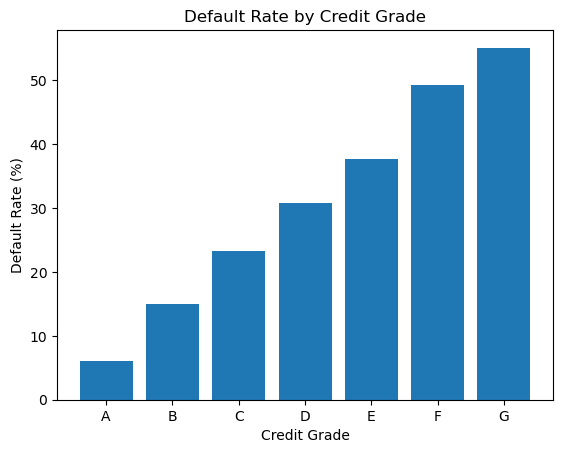

Highest default rate: G - 55.12 %
Lowest default rate: A - 6.08 %


In [7]:
table = default_table("grade")
print(table)

plt.bar(table.index.astype(str), table["Default_Rate_%"])
plt.title("Default Rate by Credit Grade")
plt.xlabel("Credit Grade")
plt.ylabel("Default Rate (%)")
plt.show()

highest_and_lowest(table)

### 6.2 By loan purpose

Purposes have long names, so this chart uses horizontal bars (`plt.barh`). Very small groups (like `wedding`, with only a few loans) can look extreme by chance.

                    Total_Loans  Defaults  Default_Rate_%
purpose                                                  
car                        1337       208           15.56
credit_card               18876      3297           17.47
home_improvement           7710      1365           17.70
vacation                    899       168           18.69
house                      1148       225           19.60
renewable_energy             66        13           19.70
major_purchase             2831       581           20.52
other                      8296      1775           21.40
debt_consolidation        55303     12234           22.12
moving                      919       210           22.85
medical                    1543       374           24.24
wedding                       3         1           33.33
small_business             1069       371           34.71


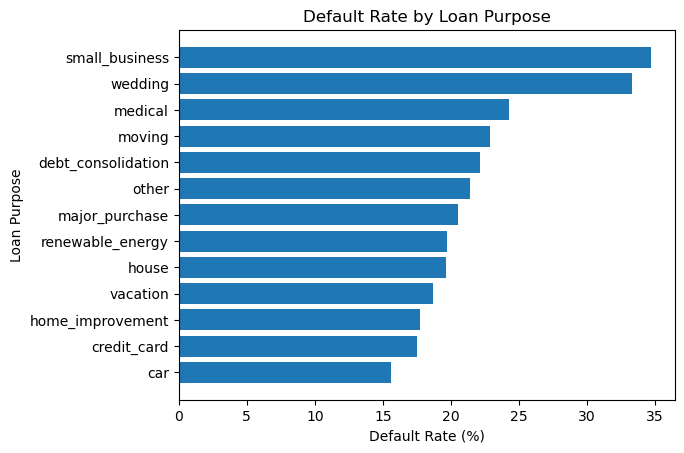

Highest default rate: small_business - 34.71 %
Lowest default rate: car - 15.56 %


In [8]:
table = default_table("purpose").sort_values("Default_Rate_%")
print(table)

plt.barh(table.index.astype(str), table["Default_Rate_%"])
plt.title("Default Rate by Loan Purpose")
plt.xlabel("Default Rate (%)")
plt.ylabel("Loan Purpose")
plt.show()

highest_and_lowest(table)

### 6.3 By annual income band

`pd.cut` puts each borrower's income into a band, e.g. below $40k, $40k–$60k, and so on.

             Total_Loans  Defaults  Default_Rate_%
income_band                                       
< $40k             14773      3844           26.02
$40k-$60k          24961      5691           22.80
$60k-$80k          22995      4721           20.53
$80k-$100k         14910      2877           19.30
$100k+             22361      3689           16.50


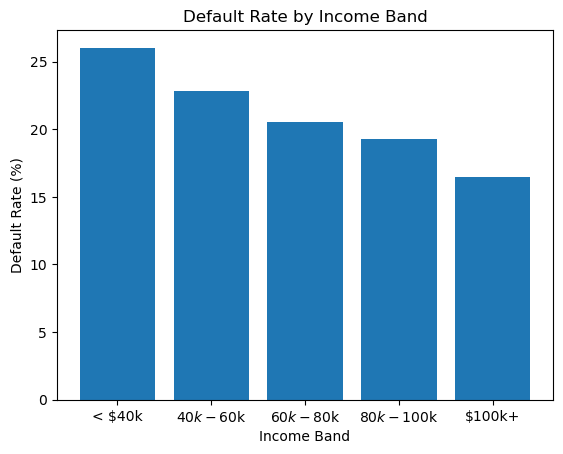

Highest default rate: < $40k - 26.02 %
Lowest default rate: $100k+ - 16.5 %


In [9]:
loans["income_band"] = pd.cut(
    loans["annual_inc"],
    bins=[-float("inf"), 40000, 60000, 80000, 100000, float("inf")],
    labels=["< $40k", "$40k-$60k", "$60k-$80k", "$80k-$100k", "$100k+"],
    right=False
)

table = default_table("income_band")
print(table)

plt.bar(table.index.astype(str), table["Default_Rate_%"])
plt.title("Default Rate by Income Band")
plt.xlabel("Income Band")
plt.ylabel("Default Rate (%)")
plt.show()

highest_and_lowest(table)

### 6.4 By DTI band

DTI (debt-to-income) = the borrower's monthly debt payments as a % of monthly income. Higher DTI means the borrower is already carrying more debt.

          Total_Loans  Defaults  Default_Rate_%
dti_band                                       
<10             21047      3553           16.88
10-20           40644      7671           18.87
20-30           28737      7009           24.39
30-40            8215      2327           28.33
40+              1242       244           19.65


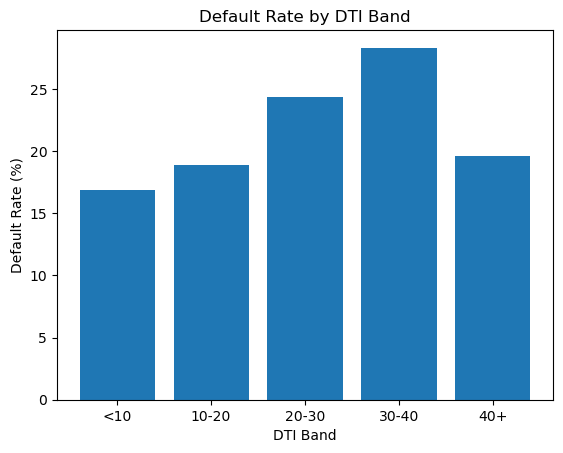

Highest default rate: 30-40 - 28.33 %
Lowest default rate: <10 - 16.88 %


In [10]:
loans["dti_band"] = pd.cut(
    loans["dti"],
    bins=[-float("inf"), 10, 20, 30, 40, float("inf")],
    labels=["<10", "10-20", "20-30", "30-40", "40+"],
    right=False
)

table = default_table("dti_band")
print(table)

plt.bar(table.index.astype(str), table["Default_Rate_%"])
plt.title("Default Rate by DTI Band")
plt.xlabel("DTI Band")
plt.ylabel("Default Rate (%)")
plt.show()

highest_and_lowest(table)

### 6.5 By interest-rate band

The lender charges riskier borrowers a higher rate, so interest rate partly reflects the lender's own view of risk.

                    Total_Loans  Defaults  Default_Rate_%
interest_rate_band                                       
<10%                      25300      2173            8.59
10-15%                    41193      8102           19.67
15-20%                    20900      5805           27.78
20-25%                     8293      2866           34.56
25%+                       4314      1876           43.49


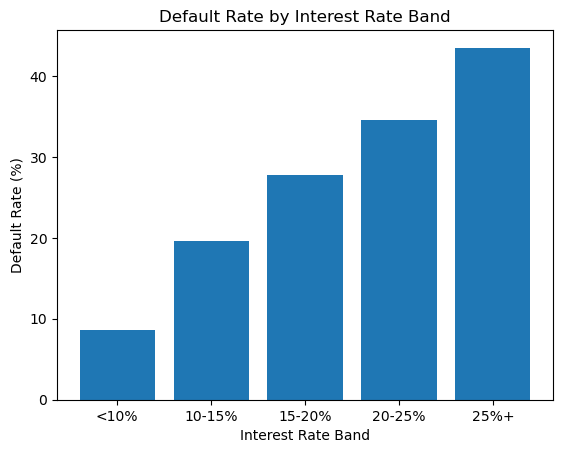

Highest default rate: 25%+ - 43.49 %
Lowest default rate: <10% - 8.59 %


In [11]:
loans["interest_rate_band"] = pd.cut(
    loans["int_rate"],
    bins=[-float("inf"), 10, 15, 20, 25, float("inf")],
    labels=["<10%", "10-15%", "15-20%", "20-25%", "25%+"],
    right=False
)

table = default_table("interest_rate_band")
print(table)

plt.bar(table.index.astype(str), table["Default_Rate_%"])
plt.title("Default Rate by Interest Rate Band")
plt.xlabel("Interest Rate Band")
plt.ylabel("Default Rate (%)")
plt.show()

highest_and_lowest(table)

### 6.6 By loan term (36 vs 60 months)

           Total_Loans  Defaults  Default_Rate_%
term                                            
36 months        75229     13733           18.25
60 months        24771      7089           28.62


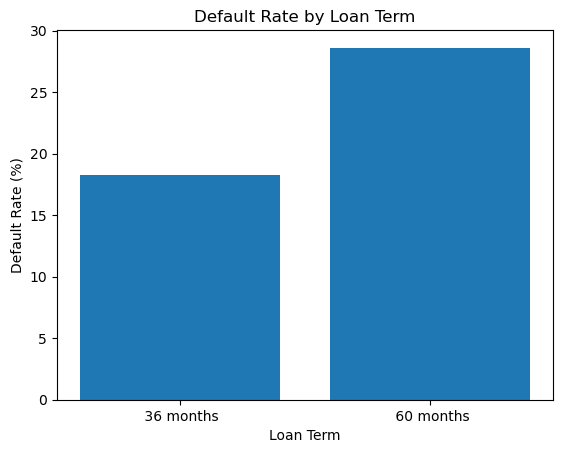

Highest default rate:  60 months - 28.62 %
Lowest default rate:  36 months - 18.25 %


In [12]:
table = default_table("term")
print(table)

plt.bar(table.index.astype(str), table["Default_Rate_%"])
plt.title("Default Rate by Loan Term")
plt.xlabel("Loan Term")
plt.ylabel("Default Rate (%)")
plt.show()

highest_and_lowest(table)

### 6.7 What the EDA shows

- **Credit grade is the clearest divider of risk.** The default rate rises at every step from grade A (6.08%) to grade G (55.12%), so grade G loans default about nine times as often as grade A loans.
- **Interest rate tells the same story.** Default rises from 8.59% for loans below 10% to 43.49% for loans at 25% and above. This makes sense, because the lender prices riskier borrowers higher.
- **Borrower finances matter.** Default falls as income rises (26.02% below $40k vs 16.50% at $100k+) and rises with DTI, from 16.88% below 10 to 28.33% at 30–40. The 40+ DTI group (19.65%) breaks the pattern, but it is small (1,242 loans) and contains extreme values such as 999, so it is treated with caution.
- **Loan features matter too.** 60-month loans default far more often than 36-month loans (28.62% vs 18.25%). By purpose, small-business loans are riskiest (34.71%) and car loans safest (15.56%). The wedding group (33.33%) has only 3 loans, so it is not meaningful.
- **Overall:** 20.82% of the 100,000 loans defaulted, and risk is concentrated in lower grades, higher interest rates, longer terms, lower incomes and higher DTI. These are patterns in the data, not proof of cause.

## Step 7: Why a scorecard, and which variables go in

A scorecard adds up points for each borrower characteristic, for example "+15 points for owning a home" or "−10 points for 3+ recent credit enquiries". It is easy to explain to a credit manager or regulator, which is why banks widely use it for approve/decline decisions.

**Variables we will test:** loan term, loan amount, annual income, DTI, revolving credit utilisation (how much of their credit-card limit a borrower is using), credit enquiries in the last 6 months, delinquencies in the last 2 years, public records, employment length, home ownership, income verification, and loan purpose.

**Left out on purpose:** `grade` and `int_rate`. These are the lender's own risk rating and the price it set *based on* that rating. Putting them in our scorecard would mean scoring borrowers with someone else's score. A real application scorecard is built from what the borrower tells us and their credit history.

## Step 8: Put every variable into bands

A scorecard gives points per **band**, not per exact value. For example, income is grouped into "<40k", "40k–60k", and so on. Text variables such as home ownership already come in groups.

The function `make_bands` does this for all variables at once. We write it as a function because we will reuse it later: for the stress test (Step 22) and to score a new applicant (Step 20).

Small details:
- `band(...)` is a helper that cuts a number column into bands and labels blanks as **"Missing"**. Missing is kept as its own band, because borrowers who don't report something can behave differently.
- Very small groups are merged into bigger ones: rare loan purposes go into "other", and the 18 "ANY" home-ownership loans go with "RENT". A band with very few loans would get unreliable points.

In [13]:
inf = float("inf")

def band(values, bins, labels):
    return pd.cut(values, bins=bins, labels=labels, right=False).astype(object).fillna("Missing")


def make_bands(data):
    bands = pd.DataFrame(index=data.index)

    bands["term"] = data["term"].str.strip()
    bands["loan_amount_band"] = band(data["loan_amnt"], [-inf, 5000, 10000, 20000, 30000, inf],
                                     ["<5k", "5k-10k", "10k-20k", "20k-30k", "30k+"])
    bands["income_band"] = band(data["annual_inc"], [-inf, 40000, 60000, 80000, 100000, inf],
                                ["<40k", "40k-60k", "60k-80k", "80k-100k", "100k+"])
    bands["dti_band"] = band(data["dti"], [-inf, 10, 20, 30, inf],
                             ["<10", "10-20", "20-30", "30+"])
    bands["revol_util_band"] = band(data["revol_util"], [-inf, 20, 40, 60, 80, inf],
                                    ["<20%", "20-40%", "40-60%", "60-80%", "80%+"])
    bands["inquiries_band"] = band(data["inq_last_6mths"], [-inf, 1, 2, 3, inf], ["0", "1", "2", "3+"])
    bands["delinquency_band"] = band(data["delinq_2yrs"], [-inf, 1, 2, inf], ["0", "1", "2+"])
    bands["public_record_band"] = band(data["pub_rec"], [-inf, 1, 2, inf], ["0", "1", "2+"])

    bands["emp_length_band"] = data["emp_length"].replace({
        "< 1 year": "0-1 years", "1 year": "0-1 years",
        "2 years": "2-5 years", "3 years": "2-5 years", "4 years": "2-5 years", "5 years": "2-5 years",
        "6 years": "6-9 years", "7 years": "6-9 years", "8 years": "6-9 years", "9 years": "6-9 years"
    }).fillna("Missing")

    bands["home_ownership"] = data["home_ownership"].replace({"ANY": "RENT", "NONE": "RENT", "OTHER": "RENT"})
    bands["verification_status"] = data["verification_status"]

    main_purposes = ["debt_consolidation", "credit_card", "home_improvement", "other",
                     "major_purchase", "medical", "small_business", "car", "house"]
    bands["purpose"] = data["purpose"].where(data["purpose"].isin(main_purposes), "other")

    return bands


loan_bands = make_bands(loans)
loan_bands.head()

,term,loan_amount_band,income_band,dti_band,revol_util_band,inquiries_band,delinquency_band,public_record_band,emp_length_band,home_ownership,verification_status,purpose
0,36 months,30k+,100k+,30+,20-40%,0,0,1,2-5 years,MORTGAGE,Verified,debt_consolidation
1,60 months,30k+,40k-60k,30+,60-80%,0,0,0,0-1 years,MORTGAGE,Verified,credit_card
2,36 months,20k-30k,100k+,10-20,20-40%,0,0,0,10+ years,MORTGAGE,Not Verified,credit_card
3,36 months,<5k,<40k,<10,<20%,0,0,0,10+ years,RENT,Not Verified,credit_card
4,36 months,5k-10k,100k+,10-20,60-80%,0,0,0,2-5 years,MORTGAGE,Verified,credit_card


## Step 9: Split into training and test data

- **80% training data**: the scorecard is built from these loans only.
- **20% test data**: kept aside and used only to check the scorecard on loans it has never seen.

`stratify` keeps the same default rate in both parts, and `random_state=42` gives the same split every time.

In [14]:
train_bands, test_bands, y_train, y_test = train_test_split(
    loan_bands, loans["default_flag"], test_size=0.20, random_state=42, stratify=loans["default_flag"]
)

print("Training loans:", len(train_bands))
print("Test loans:", len(test_bands))

Training loans: 80000
Test loans: 20000


## Step 10: Weight of Evidence (WOE) and Information Value (IV)

In scorecard language, a **"good"** borrower repaid and a **"bad"** borrower defaulted.

**WOE** (for each band) = ln( % of all goods in this band ÷ % of all bads in this band )
- WOE above 0 → the band has relatively more good borrowers → safer.
- WOE below 0 → relatively more bad borrowers → riskier.

**IV** (for the whole variable) adds up, across bands, (% goods − % bads) × WOE. It tells us how useful the variable is for separating goods from bads. A common rule of thumb:

| IV | Meaning |
|---|---|
| below 0.02 | not useful |
| 0.02 – 0.1 | weak |
| 0.1 – 0.3 | medium |
| above 0.3 | strong |

WOE and IV are calculated **from training data only**. The function takes the bands and the default flag as inputs, so we can reuse it for the out-of-time check in Step 14.2.

In [15]:
def woe_table(column, bands_data, target):
    table = pd.DataFrame({"band": bands_data[column], "bad": target})
    table = table.groupby("band")["bad"].agg(["count", "sum"])
    table.columns = ["Total", "Bad"]
    table["Good"] = table["Total"] - table["Bad"]

    table["Pct_Good"] = table["Good"] / table["Good"].sum()
    table["Pct_Bad"] = table["Bad"] / table["Bad"].sum()
    table["WOE"] = np.log(table["Pct_Good"] / table["Pct_Bad"])
    table["IV_part"] = (table["Pct_Good"] - table["Pct_Bad"]) * table["WOE"]

    return table.sort_values("WOE")   # riskiest band first


all_variables = list(loan_bands.columns)
woe_tables = {}

for variable in all_variables:
    woe_tables[variable] = woe_table(variable, train_bands, y_train)
    print("=====", variable, "=====")
    print(woe_tables[variable][["Total", "Bad", "WOE"]].round(3))
    print()

===== term =====
           Total    Bad    WOE
band                          
60 months  19778   5668 -0.424
36 months  60222  10990  0.164

===== loan_amount_band =====
         Total   Bad    WOE
band                       
30k+      8641  2112 -0.207
20k-30k  13751  3344 -0.200
10k-20k  29007  6351 -0.064
5k-10k   19056  3478  0.164
<5k       9545  1373  0.448

===== income_band =====
          Total   Bad    WOE
band                        
<40k      11806  3089 -0.298
40k-60k   19945  4554 -0.118
60k-80k   18454  3738  0.035
80k-100k  11951  2322  0.087
100k+     17844  2955  0.281

===== dti_band =====
         Total   Bad    WOE
band                       
30+       7587  2083 -0.364
20-30    22959  5606 -0.206
10-20    32579  6139  0.125
Missing     95    17  0.188
<10      16780  2813  0.267

===== revol_util_band =====
         Total   Bad    WOE
band                       
80%+      8030  2084 -0.287
60-80%   14740  3724 -0.251
40-60%   20266  4611 -0.113
20-40%   20970  38

### 10.1 IV of every variable

               Variable      IV
10  verification_status  0.0701
0                  term  0.0690
9        home_ownership  0.0671
4       revol_util_band  0.0613
3              dti_band  0.0467
1      loan_amount_band  0.0407
2           income_band  0.0354
11              purpose  0.0260
5        inquiries_band  0.0255
8       emp_length_band  0.0225
7    public_record_band  0.0071
6      delinquency_band  0.0064


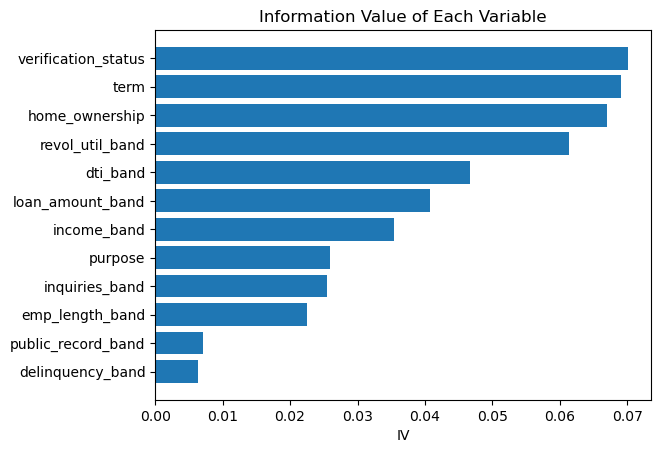

In [16]:
iv_summary = pd.DataFrame({
    "Variable": all_variables,
    "IV": [woe_tables[v]["IV_part"].sum() for v in all_variables]
}).sort_values("IV")

print(iv_summary.sort_values("IV", ascending=False).round(4))

plt.barh(iv_summary["Variable"], iv_summary["IV"])
plt.title("Information Value of Each Variable")
plt.xlabel("IV")
plt.show()

## Step 11: Keep only useful variables

We keep variables with IV of at least 0.02. The others add little and would only make the scorecard longer.

Expect the IVs to be in the "weak" range. This is normal once `grade` and `int_rate` are excluded, because no single borrower detail predicts default strongly on its own. The scorecard's strength comes from combining them.

In [17]:
selected_variables = list(iv_summary[iv_summary["IV"] >= 0.02]["Variable"])

print("Selected:", selected_variables)
print("Dropped:", [v for v in all_variables if v not in selected_variables])

Selected: ['emp_length_band', 'inquiries_band', 'purpose', 'income_band', 'loan_amount_band', 'dti_band', 'revol_util_band', 'home_ownership', 'term', 'verification_status']
Dropped: ['delinquency_band', 'public_record_band']


## Step 12: Replace each band with its WOE value

The model needs numbers, so every band is replaced by its WOE number from Step 10. For example, a borrower in "RENT" gets the WOE of RENT.

If a band ever appears that was not seen in training, it gets WOE = 0 (neutral). We write this as a function too, so we can reuse it later.

In [18]:
def to_woe(bands, tables):
    woe_values = pd.DataFrame(index=bands.index)
    for variable in selected_variables:
        woe_values[variable] = bands[variable].map(tables[variable]["WOE"]).fillna(0)
    return woe_values


X_train = to_woe(train_bands, woe_tables)
X_test = to_woe(test_bands, woe_tables)
X_train.head()

,emp_length_band,inquiries_band,purpose,income_band,loan_amount_band,dti_band,revol_util_band,home_ownership,term,verification_status
6711,0.001547,0.118698,0.028657,0.034727,0.448058,0.124558,-0.251108,-0.291373,0.163900,0.437224
30052,0.001547,0.118698,-0.082445,-0.117881,0.163744,0.124558,0.145420,0.265960,0.163900,-0.161157
39830,0.001547,0.118698,0.203669,-0.298230,-0.207040,-0.363992,0.421846,0.265960,0.163900,0.437224
44489,0.115807,-0.080959,-0.082445,0.034727,-0.063846,-0.363992,0.145420,0.265960,-0.423611,-0.161157
60630,0.115807,0.118698,0.229429,0.281466,-0.063846,0.124558,-0.251108,0.265960,-0.423611,0.437224


### 12.1 Correlation check between variables

If two variables carry almost the same information (for example income and DTI), the model can split their effect between them in odd ways, and their points become unreliable. This is called **multicollinearity**.

We look at the correlation between every pair of WOE variables. A common rule is to review any pair above **0.6** (positive or negative) and drop the one with the lower IV.

In [19]:
correlations = X_train.corr()
print(correlations.round(2))

print()
print("Pairs with correlation above 0.6:")
found = False
for i in range(len(selected_variables)):
    for j in range(i + 1, len(selected_variables)):
        value = correlations.iloc[i, j]
        if abs(value) > 0.6:
            print(selected_variables[i], "and", selected_variables[j], ":", round(value, 2))
            found = True

if not found:
    print("None. No variable needs to be dropped for high correlation.")

                     emp_length_band  inquiries_band  purpose  income_band  \
emp_length_band                 1.00           -0.00    -0.00         0.26   
inquiries_band                 -0.00            1.00     0.00        -0.05   
purpose                        -0.00            0.00     1.00         0.02   
income_band                     0.26           -0.05     0.02         1.00   
loan_amount_band               -0.09           -0.01     0.04        -0.35   
dti_band                        0.02            0.00     0.02         0.18   
revol_util_band                -0.06           -0.11     0.01        -0.08   
home_ownership                  0.07           -0.01     0.06         0.23   
term                           -0.05            0.01     0.03        -0.11   
verification_status            -0.00            0.07     0.07         0.04   

                     loan_amount_band  dti_band  revol_util_band  \
emp_length_band                 -0.09      0.02            -0.06   
inqui

## Step 13: Fit the Logistic Regression

Logistic Regression learns one weight (coefficient) per variable.

Unlike before, we do **not** use `class_weight="balanced"`. That setting pushes predicted probabilities above the real default rate. Without it, the model's probabilities can be used directly as a **PD (probability of default)** for Expected Loss later.

**Sign check:** because higher WOE means safer, every coefficient should be **negative** (safer → lower chance of default). A positive coefficient would mean the variable behaves oddly next to the others and should be reviewed.

In [20]:
scorecard_model = LogisticRegression(max_iter=1000)
scorecard_model.fit(X_train, y_train)

coefficients = pd.DataFrame({
    "Variable": selected_variables,
    "Coefficient": scorecard_model.coef_[0]
})
print(coefficients.round(3))
print("Intercept:", round(scorecard_model.intercept_[0], 3))
print("All coefficients negative:", (coefficients["Coefficient"] < 0).all())

              Variable  Coefficient
0      emp_length_band       -0.942
1       inquiries_band       -1.237
2              purpose       -0.760
3          income_band       -1.026
4     loan_amount_band       -0.945
5             dti_band       -0.621
6      revol_util_band       -0.996
7       home_ownership       -1.044
8                 term       -0.874
9  verification_status       -0.756
Intercept: -1.339
All coefficients negative: True


## Step 14: How good is the model?

We check four things on both training and test data. If test results are much worse than training results, the model has memorised the training data (overfitting).

| Measure | Plain meaning |
|---|---|
| AUC | Pick one defaulter and one non-defaulter at random: how often does the model give the defaulter the higher risk? 0.5 = coin toss, 1.0 = perfect. |
| Gini | 2 × AUC − 1. The same idea on a 0-to-1 scale; banks usually quote Gini. |
| KS | The biggest gap, at any cut-off, between the share of defaulters caught and the share of good borrowers wrongly caught. Higher = better separation. |
| Average PD vs actual default rate | If these two are close, the model's probabilities are realistic. |

In [21]:
train_pd = scorecard_model.predict_proba(X_train)[:, 1]
test_pd = scorecard_model.predict_proba(X_test)[:, 1]


def model_check(actual, predicted_pd):
    auc = roc_auc_score(actual, predicted_pd)
    false_positive_rate, true_positive_rate, _ = roc_curve(actual, predicted_pd)
    ks = max(true_positive_rate - false_positive_rate)
    return {
        "AUC": round(auc, 3),
        "Gini": round(2 * auc - 1, 3),
        "KS": round(ks, 3),
        "Average PD (%)": round(predicted_pd.mean() * 100, 2),
        "Actual default rate (%)": round(actual.mean() * 100, 2),
    }


pd.DataFrame([model_check(y_train, train_pd), model_check(y_test, test_pd)], index=["Train", "Test"])

,AUC,Gini,KS,Average PD (%),Actual default rate (%)
Train,0.677,0.354,0.255,20.82,20.82
Test,0.674,0.347,0.249,20.72,20.82


### 14.1 ROC curve

The ROC curve shows, for every possible cut-off, the share of defaulters caught (up) against the share of good borrowers wrongly caught (across). The further the curve bends above the diagonal line, the better. The diagonal is what random guessing would give.

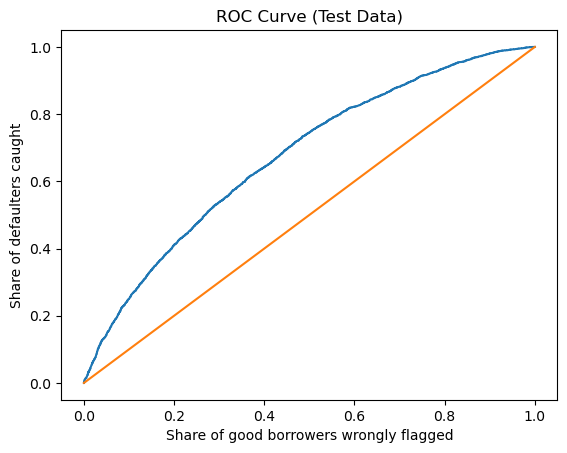

In [22]:
false_positive_rate, true_positive_rate, _ = roc_curve(y_test, test_pd)

plt.plot(false_positive_rate, true_positive_rate)
plt.plot([0, 1], [0, 1])
plt.title("ROC Curve (Test Data)")
plt.xlabel("Share of good borrowers wrongly flagged")
plt.ylabel("Share of defaulters caught")
plt.show()

## Step 15: Comparison with a more complex model (XGBoost)

A fair question in any interview is: "would a more complex model do much better?" We train XGBoost on **exactly the same inputs** and compare only the AUC.

If the gain is small, the scorecard is the better choice, because every point in it can be explained, and a complex model's cannot.

In [25]:
from xgboost import XGBClassifier 
xgb_model = XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)

xgb_test_pd = xgb_model.predict_proba(X_test)[:, 1]

print("Scorecard (Logistic Regression) test AUC:", round(roc_auc_score(y_test, test_pd), 3))
print("XGBoost test AUC:", round(roc_auc_score(y_test, xgb_test_pd), 3))

Scorecard (Logistic Regression) test AUC: 0.674
XGBoost test AUC: 0.679


## Step 15.1: Out-of-time validation

So far the test data was a random 20% of loans, so it came from the same years as the training data. Banks also check a scorecard on a **later period**, because it will be used on future applicants.

Here we rebuild the same scorecard (same bands, same selected variables, same method) using **only 2016 loans**, and then test it on **2018 loans** it has never seen.

- If the 2018 AUC stays close to the 2016 AUC, the scorecard's ranking holds up over time.
- The average PD may differ from the 2018 default rate, because default rates change over time. That is normal, and is why banks recalibrate PDs regularly.

In [26]:
is_2016 = loans["issue_d"].str.endswith("16")
is_2018 = loans["issue_d"].str.endswith("18")

bands_2016 = loan_bands[is_2016]
y_2016 = loans.loc[is_2016, "default_flag"]
bands_2018 = loan_bands[is_2018]
y_2018 = loans.loc[is_2018, "default_flag"]

print("2016 loans (build):", len(bands_2016))
print("2018 loans (test):", len(bands_2018))

# Rebuild WOE tables from 2016 loans only
woe_tables_2016 = {}
for variable in selected_variables:
    woe_tables_2016[variable] = woe_table(variable, bands_2016, y_2016)

X_2016 = to_woe(bands_2016, woe_tables_2016)
X_2018 = to_woe(bands_2018, woe_tables_2016)

model_2016 = LogisticRegression(max_iter=1000)
model_2016.fit(X_2016, y_2016)

pd_2016 = model_2016.predict_proba(X_2016)[:, 1]
pd_2018 = model_2016.predict_proba(X_2018)[:, 1]

pd.DataFrame([model_check(y_2016, pd_2016), model_check(y_2018, pd_2018)],
             index=["2016 (built on)", "2018 (out of time)"])

2016 loans (build): 52809
2018 loans (test): 47191


,AUC,Gini,KS,Average PD (%),Actual default rate (%)
2016 (built on),0.665,0.329,0.233,26.28,26.27
2018 (out of time),0.673,0.345,0.252,24.57,14.73


## Step 16: Turn the model into points (the scorecard)

We use the common industry convention:
- A score of **600** means odds of **50 good : 1 bad**.
- Every **20 points** more (PDO, "points to double the odds") doubles the odds of being good.

From these two choices we get two constants:
- Factor = 20 ÷ ln(2)
- Offset = 600 − Factor × ln(50)

The points for each band are:

Points = −(coefficient × WOE + intercept ÷ number of variables) × Factor + Offset ÷ number of variables

You don't need to memorise the formula. The idea is that the model's logic is spread across the variables so that **adding up a borrower's points gives their score**. The resulting table is the scorecard itself.

In [27]:
PDO = 20
BASE_SCORE = 600
BASE_ODDS = 50

factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)

number_of_variables = len(selected_variables)
intercept = scorecard_model.intercept_[0]
coefficient = dict(zip(selected_variables, scorecard_model.coef_[0]))

print("Factor:", round(factor, 2))
print("Offset:", round(offset, 2))


def band_points(variable, woe):
    return -(coefficient[variable] * woe + intercept / number_of_variables) * factor + offset / number_of_variables


scorecard_rows = []
for variable in selected_variables:
    for band_name, row in woe_tables[variable].iterrows():
        scorecard_rows.append({
            "Variable": variable,
            "Band": band_name,
            "WOE": round(row["WOE"], 3),
            "Points": round(band_points(variable, row["WOE"]))
        })

scorecard = pd.DataFrame(scorecard_rows)
scorecard

Factor: 28.85
Offset: 487.12


,Variable,Band,WOE,Points
0,emp_length_band,Missing,-0.463,40
1,emp_length_band,0-1 years,-0.048,51
2,emp_length_band,2-5 years,0.002,53
3,emp_length_band,6-9 years,0.043,54
4,emp_length_band,10+ years,0.116,56
5,inquiries_band,3+,-0.459,36
6,inquiries_band,2,-0.248,44
7,inquiries_band,1,-0.081,50
8,inquiries_band,0,0.119,57
9,purpose,small_business,-0.726,37


**How to read the scorecard:** within each variable, the riskiest band gets the fewest points. For example, compare RENT and MORTGAGE under home ownership, or "3+" and "0" under recent enquiries.

## Step 17: Score every test loan

A loan's score is the sum of its points across all variables. The histogram shows how scores are spread.

count    20000.0
mean       530.6
std         19.6
min        463.0
25%        517.0
50%        530.0
75%        544.0
max        598.0
dtype: float64


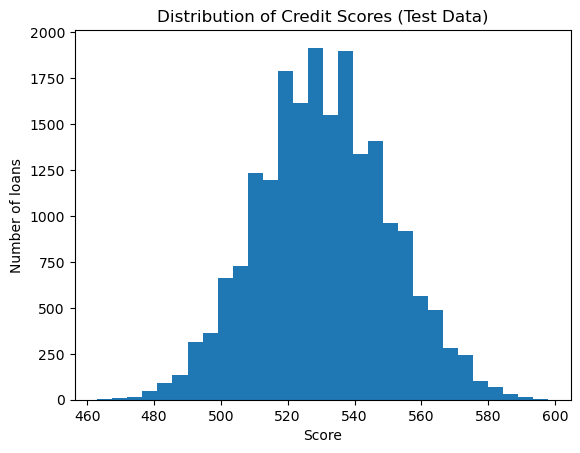

In [30]:
def calculate_score(woe_values):
    score = 0
    for variable in selected_variables:
        score = score + band_points(variable, woe_values[variable]).round()
    return score


test_scores = calculate_score(X_test)
print(test_scores.describe().round(1))

plt.hist(test_scores, bins=30)
plt.title("Distribution of Credit Scores (Test Data)")
plt.xlabel("Score")
plt.ylabel("Number of loans")
plt.show()

## Step 18: Default rate by score band

This is the most important business check. The **actual** default rate should fall steadily as the score rises. If it does, the scorecard ranks borrowers correctly.

            Loans  Average_PD  Actual_Default_Rate  Share_of_Loans_%
score_band                                                          
<510         2822       39.89                39.40             14.11
510-520      3025       28.42                27.80             15.12
520-530      3851       22.19                22.64             19.26
530-540      3872       16.85                17.56             19.36
540-550      3002       12.67                13.32             15.01
550+         3428        7.93                 7.56             17.14


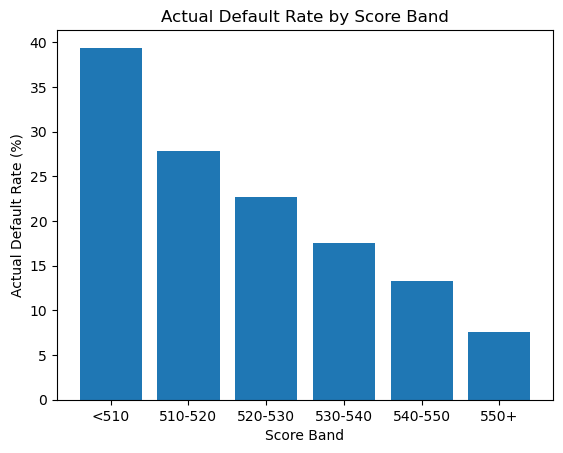

In [31]:
results = pd.DataFrame({
    "score": test_scores,
    "pd": test_pd,
    "actual_default": y_test,
    "loan_amnt": loans.loc[test_bands.index, "loan_amnt"],
    "issue_year": "20" + loans.loc[test_bands.index, "issue_d"].str[-2:]
})

results["score_band"] = pd.cut(results["score"], bins=[-inf, 510, 520, 530, 540, 550, inf],
                               labels=["<510", "510-520", "520-530", "530-540", "540-550", "550+"], right=False)

score_band_summary = results.groupby("score_band", observed=False).agg(
    Loans=("actual_default", "count"),
    Average_PD=("pd", "mean"),
    Actual_Default_Rate=("actual_default", "mean"),
)
score_band_summary["Share_of_Loans_%"] = score_band_summary["Loans"] / len(results) * 100
score_band_summary["Average_PD"] = score_band_summary["Average_PD"] * 100
score_band_summary["Actual_Default_Rate"] = score_band_summary["Actual_Default_Rate"] * 100

print(score_band_summary.round(2))

plt.bar(score_band_summary.index.astype(str), score_band_summary["Actual_Default_Rate"])
plt.title("Actual Default Rate by Score Band")
plt.xlabel("Score Band")
plt.ylabel("Actual Default Rate (%)")
plt.show()

## Step 19: Choosing an approval cut-off

A lender approves applicants whose score is at or above a **cut-off**. Raising the cut-off approves fewer people but with fewer defaults among them. This table shows the trade-off:

- **Approval rate:** % of applicants approved.
- **Bad rate of approved:** % of approved loans that defaulted.
- **Bad rate of declined:** % of declined loans that would have defaulted. This should be clearly higher, otherwise we are turning away good customers for nothing.

Choosing the cut-off is a business decision: how much growth the lender wants versus how much risk it can accept (its **risk appetite**).

   Cut-off  Approval_Rate_%  Bad_Rate_Approved_%  Bad_Rate_Declined_%
0      500            94.56                19.39                45.64
1      510            85.89                17.77                39.40
2      520            70.76                15.62                33.40
3      530            51.51                13.00                29.13
4      540            32.15                10.25                25.83
5      550            17.14                 7.56                23.56
6      560             7.52                 4.52                22.14


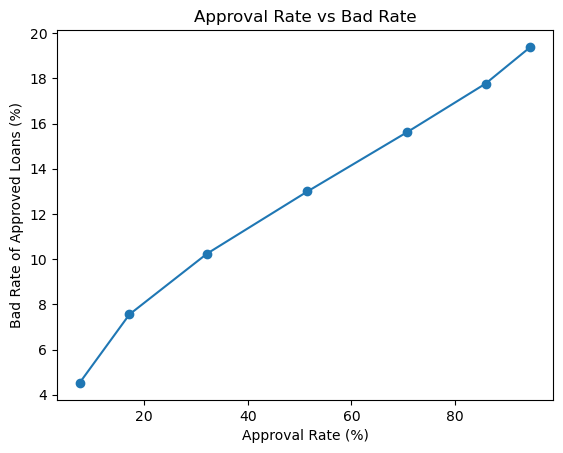

In [32]:
cutoff_rows = []
for cutoff in range(500, 561, 10):
    approved = results[results["score"] >= cutoff]
    declined = results[results["score"] < cutoff]
    cutoff_rows.append({
        "Cut-off": cutoff,
        "Approval_Rate_%": len(approved) / len(results) * 100,
        "Bad_Rate_Approved_%": approved["actual_default"].mean() * 100,
        "Bad_Rate_Declined_%": declined["actual_default"].mean() * 100,
    })

cutoff_table = pd.DataFrame(cutoff_rows)
print(cutoff_table.round(2))

plt.plot(cutoff_table["Approval_Rate_%"], cutoff_table["Bad_Rate_Approved_%"], marker="o")
plt.title("Approval Rate vs Bad Rate")
plt.xlabel("Approval Rate (%)")
plt.ylabel("Bad Rate of Approved Loans (%)")
plt.show()

## Step 20: Scoring a new applicant

This is how the scorecard would be used in practice. We take one borrower's raw details, put them into bands, look up the points for each band, and add them up. Here we use the first loan in the test data as a stand-in for a new applicant.

Change `CUTOFF` to whatever cut-off you pick in Step 19.

In [33]:
CUTOFF = 520

applicant = loans.loc[[test_bands.index[0]]]
applicant_bands = make_bands(applicant)
applicant_woe = to_woe(applicant_bands, woe_tables)

breakdown = pd.DataFrame({
    "Variable": selected_variables,
    "Applicant's band": [applicant_bands[v].iloc[0] for v in selected_variables],
    "Points": [round(band_points(v, applicant_woe[v].iloc[0])) for v in selected_variables]
})
print(breakdown)

applicant_score = breakdown["Points"].sum()
print()
print("Total score:", applicant_score)
print("Predicted PD (%):", round(scorecard_model.predict_proba(applicant_woe)[0, 1] * 100, 2))
print("Decision:", "APPROVE" if applicant_score >= CUTOFF else "DECLINE")

              Variable    Applicant's band  Points
0      emp_length_band           6-9 years      54
1       inquiries_band                   0      57
2              purpose  debt_consolidation      51
3          income_band               100k+      61
4     loan_amount_band                30k+      47
5             dti_band                 <10      57
6      revol_util_band              60-80%      45
7       home_ownership                RENT      44
8                 term           36 months      57
9  verification_status            Verified      49

Total score: 522
Predicted PD (%): 23.34
Decision: APPROVE


## Step 21: Expected Loss

Expected Loss = PD × LGD × EAD

- **PD** (probability of default): from the scorecard model. Its probabilities were shown to be realistic in Step 14.
- **LGD** (loss given default): share of the loan lost if the borrower defaults. We **assume 45%**; this dataset does not let us estimate it.
- **EAD** (exposure at default): amount owed at default. We use the original loan amount as a simple stand-in (in reality part of it would already be repaid).

Because LGD is assumed and EAD is simplified, treat these values as illustrative.

Total exposure: 289938525
Total expected loss: 29172494
Expected loss as % of exposure: 10.06

            Exposure  Expected_Loss  EL_%_of_Exposure
score_band                                           
<510        49775250     8962033.50             18.00
510-520     50014575     6399717.69             12.80
520-530     60568700     6062180.95             10.01
530-540     56029175     4259879.22              7.60
540-550     38044125     2181604.56              5.73
550+        35506700     1307077.78              3.68


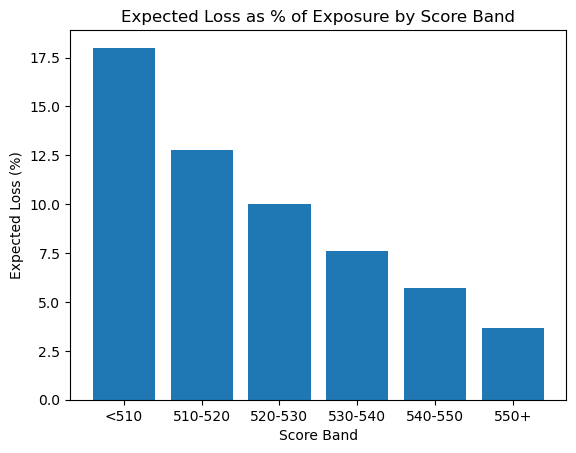

In [34]:
LGD = 0.45

results["expected_loss"] = results["pd"] * LGD * results["loan_amnt"]

print("Total exposure:", round(results["loan_amnt"].sum()))
print("Total expected loss:", round(results["expected_loss"].sum()))
print("Expected loss as % of exposure:", round(results["expected_loss"].sum() / results["loan_amnt"].sum() * 100, 2))

el_by_band = results.groupby("score_band", observed=False).agg(
    Exposure=("loan_amnt", "sum"),
    Expected_Loss=("expected_loss", "sum"),
)
el_by_band["EL_%_of_Exposure"] = el_by_band["Expected_Loss"] / el_by_band["Exposure"] * 100
print()
print(el_by_band.round(2))

plt.bar(el_by_band.index.astype(str), el_by_band["EL_%_of_Exposure"])
plt.title("Expected Loss as % of Exposure by Score Band")
plt.xlabel("Score Band")
plt.ylabel("Expected Loss (%)")
plt.show()

## Step 22: Simple stress test

What if the economy worsens and borrowers come under pressure? We change the raw data for the test loans, re-score them with the **same** scorecard, and see how PD and Expected Loss move.

| Scenario | What we change |
|---|---|
| Base | nothing |
| Mild stress | DTI up 10%, income down 5% |
| Severe stress | DTI up 25%, income down 15% |

This is a simple sensitivity test: it only moves the variables we chose, and the shock sizes are assumptions, not a full economic model.

        Scenario  Average_PD_%  Expected_Loss  Change_vs_Base_%
0           Base         20.72    29172493.70              0.00
1    Mild stress         21.56    30317238.92              3.92
2  Severe stress         22.64    31821178.65              9.08


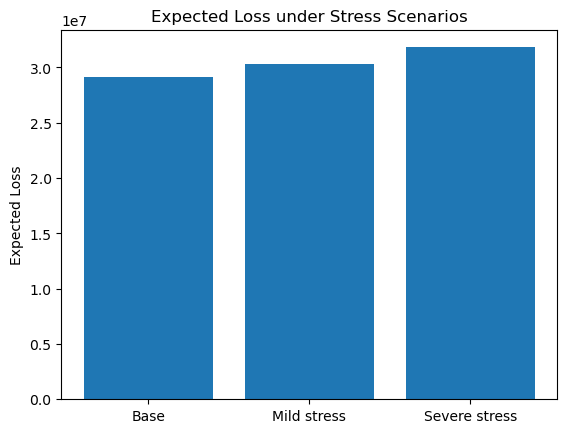

In [35]:
scenarios = {
    "Base": (1.00, 1.00),
    "Mild stress": (1.10, 0.95),
    "Severe stress": (1.25, 0.85),
}

test_loans = loans.loc[test_bands.index]
stress_rows = []

for scenario_name, (dti_change, income_change) in scenarios.items():
    shocked = test_loans.copy()
    shocked["dti"] = shocked["dti"] * dti_change
    shocked["annual_inc"] = shocked["annual_inc"] * income_change

    shocked_pd = scorecard_model.predict_proba(to_woe(make_bands(shocked), woe_tables))[:, 1]
    shocked_el = (shocked_pd * LGD * shocked["loan_amnt"]).sum()

    stress_rows.append({
        "Scenario": scenario_name,
        "Average_PD_%": shocked_pd.mean() * 100,
        "Expected_Loss": shocked_el,
    })

stress_table = pd.DataFrame(stress_rows)
base_el = stress_table.loc[0, "Expected_Loss"]
stress_table["Change_vs_Base_%"] = (stress_table["Expected_Loss"] / base_el - 1) * 100
print(stress_table.round(2))

plt.bar(stress_table["Scenario"], stress_table["Expected_Loss"])
plt.title("Expected Loss under Stress Scenarios")
plt.ylabel("Expected Loss")
plt.show()

## Step 23: Stability check (PSI)

After a bank launches a scorecard, it checks regularly whether today's applicants still look like the ones the scorecard was built on. If the population shifts a lot, the scorecard may need rebuilding.

The standard measure is the **Population Stability Index (PSI)**. We compare the score-band mix of the 2016 loans against the 2018 loans in the test data:

PSI = sum over bands of (% in 2018 − % in 2016) × ln(% in 2018 ÷ % in 2016)

| PSI | Meaning |
|---|---|
| below 0.10 | stable |
| 0.10 – 0.25 | some shift, keep watching |
| above 0.25 | big shift, review the scorecard |

In [36]:
band_mix = pd.crosstab(results["score_band"], results["issue_year"], normalize="columns")
print("Share of loans in each score band, by year:")
print((band_mix * 100).round(2))

share_2016 = band_mix["2016"]
share_2018 = band_mix["2018"]
psi = ((share_2018 - share_2016) * np.log(share_2018 / share_2016)).sum()

print()
print("PSI (2016 vs 2018):", round(psi, 4))

Share of loans in each score band, by year:
issue_year   2016   2018
score_band              
<510        15.89  12.17
510-520     16.90  13.18
520-530     20.27  18.14
530-540     19.51  19.20
540-550     13.89  16.24
550+        13.54  21.07

PSI (2016 vs 2018): 0.0586


## Step 24: Conclusions

**Portfolio findings (EDA):** Of 100,000 finished loans worth about $1.45 billion, 20.82% defaulted. Default risk was highest for grade G (55.12%), loans priced at 25%+ interest (43.49%), small-business loans (34.71%), 60-month terms (28.62%), DTI of 30–40 (28.33%) and incomes below $40k (26.02%).

**Scorecard:** Of 12 candidate variables, 10 passed the IV ≥ 0.02 filter. The strongest were verification status (IV 0.070), term (0.069), home ownership (0.067) and revolving utilisation (0.061). Delinquencies (0.006) and public records (0.007) were dropped. All IVs fall in the "weak" range, which is expected once grade and interest rate are excluded. No pair of variables had a correlation above 0.6; the highest was term and loan amount at 0.41. All 10 coefficients were negative, as expected.

**Model quality:**
- **Ranking power:** test AUC was 0.674 (Gini 0.347, KS 0.249), almost identical to training (AUC 0.677), so the model is not overfitting.
- **Calibration:** average predicted PD on test data (20.72%) closely matched the actual default rate (20.82%), so the probabilities are realistic.
- **Complex model comparison:** XGBoost on the same inputs reached AUC 0.679, a gain of only 0.005, which does not justify giving up the scorecard's explainability.
- **Out-of-time check:** built on 2016 loans, the scorecard ranked 2018 loans just as well (AUC 0.673 vs 0.665). However, it predicted a 24.57% default rate for 2018 against an actual 14.73%. The ranking holds over time, but the PD level would need recalibrating for a new period, partly because of the finished-loans bias (see Step 25).

**Business use:**
- **Score bands:** the actual default rate fell at every step, from 39.40% in the lowest band (<510) to 7.56% in the highest (550+), so the scorecard ranks borrowers correctly. Predicted PDs in each band were close to the actual rates.
- **Suggested cut-off: 520.** It approves 70.76% of applicants with a 15.62% bad rate, against 20.82% if everyone were approved. The declined group has a 33.40% bad rate, so the lender turns away mostly risky borrowers. Moving to 530 would lower the bad rate by only another 2.6 points (to 13.00%) but cut approvals to 51.51%. The final choice would depend on the lender's risk appetite.
- **Expected Loss:** with an assumed LGD of 45%, Expected Loss on the test portfolio was about $29.2 million, or 10.06% of the $289.9 million exposure. It ranged from 18.00% of exposure in the lowest score band to 3.68% in the highest.
- **Stress test:** Expected Loss rose by 3.92% under mild stress (DTI +10%, income −5%) and by 9.08% under severe stress (DTI +25%, income −15%).
- **Stability:** PSI between 2016 and 2018 loans was 0.059, below 0.10, so the population is stable. The 2018 loans were somewhat more concentrated in the higher score bands (21.07% in 550+ vs 13.54% in 2016).

**Interview summary:**

> "I built an application scorecard on 100,000 LendingClub loans. After EDA, I grouped each borrower variable into bands and used Weight of Evidence and Information Value to select 10 of 12 variables. I deliberately left out grade and interest rate, because they are the lender's own risk rating. I checked that no variables were highly correlated, fitted a Logistic Regression on the WOE values, confirmed all coefficients had the expected sign, and converted it into a points-based scorecard using a 600-points-at-50:1-odds, 20-PDO scaling. On held-out data it achieved a Gini of 0.35, held up on out-of-time 2018 loans, and was only 0.005 AUC behind XGBoost. I then used it end to end: default rates fell from 39% to 8% across score bands, a 520 cut-off approved 71% of applicants at a 15.6% bad rate against 20.8% overall, Expected Loss was about 10% of exposure using PD × LGD × EAD with an assumed LGD, it rose 9% under a severe DTI and income stress, and the PSI of 0.06 showed a stable population."

## Step 25: Limitations (and how to explain them)

**1. Reject inference.** The data only contains loans that were **approved**. We never see how rejected applicants would have behaved, so the scorecard is built on an already-filtered population and may understate risk for the kind of applicants the lender used to reject. Banks handle this with **reject inference** techniques, which need data on rejected applications. This dataset has none, so it is noted as a limitation.

**2. Finished-loans bias.** We kept only loans that had ended (Fully Paid or Charged Off). For the newer 2018 loans, a loan that had already ended by the data date was either repaid early or defaulted early, so these loans are not fully representative of all 2018 borrowers. This also affects the 2018 comparisons in Steps 15.1 and 23. With more time, the fix is to use only loan years old enough for most loans to have finished.

**3. LGD and EAD are simplified.** LGD is an assumed 45% and EAD is the original loan amount. In practice LGD is modelled from recovery data (what the lender actually got back after default), and EAD from the remaining balance at the time of default. Expected Loss here is illustrative.

**4. No p-values.** scikit-learn's Logistic Regression does not report whether each coefficient is statistically significant. Here, every variable passed the IV filter (Step 11), the correlation check (Step 12.1) and the sign check (Step 13). If p-values are needed, the `statsmodels` library reports them for the same model.